Task 2

In [62]:
import numpy as np
import matplotlib.pyplot as plt

In [63]:
test_in = np.genfromtxt('data/test_in - Copy.csv', delimiter=',')
test_out = np.genfromtxt('data/test_out - Copy.csv', delimiter=',', dtype=int)
train_in = np.genfromtxt('data/train_in - Copy.csv', delimiter=',')
train_out = np.genfromtxt('data/train_out - Copy.csv', delimiter=',', dtype=int)

In [64]:
class MultiClassPerceptron():
    def __init__(self, num_input, num_classes):
        self.number_weight = num_input + 1
        self.num_classes = num_classes
        self.weight = np.random.normal(0, 1, (self.number_weight, self.num_classes))/(num_input*num_classes)
    
    def train(self, input, output, n_steps=1000, learning_rate=1e-6):
        input_plus_bias = np.hstack([input, np.ones((input.shape[0], 1))])
        self.loss = np.zeros(n_steps)
        self.learning_rate = np.zeros(n_steps)
        for i in range(n_steps):
            model = input_plus_bias @ self.weight
            residual = model - output
            self.loss[i] = np.sum((model - output)**2)


            gradient =  2 * input_plus_bias.T @ residual
                
            self.weight -= learning_rate * gradient
    
    def predict(self, input):
        input_plus_bias = np.hstack([input, np.ones((input.shape[0], 1))])
        model = input_plus_bias @ self.weight
        return model




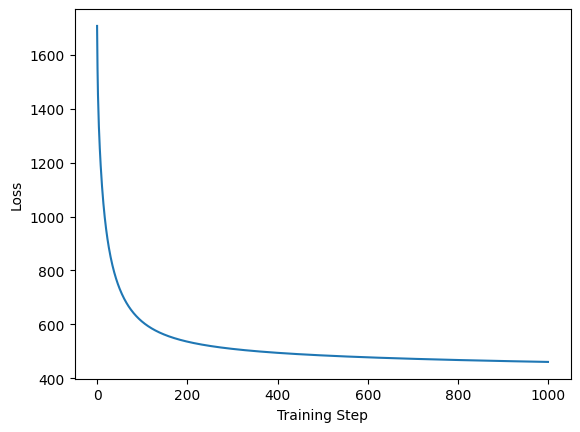

In [70]:
classifier = MultiClassPerceptron(256, 10)

vector_label = np.eye(10)[train_out]

classifier.train(train_in, vector_label, 1000, learning_rate=1e-6)

plt.plot(classifier.loss)
# plt.yscale('log')
plt.xlabel('Training Step')
plt.ylabel('Loss')
plt.show()

In [71]:
digits = np.arange(10)
prediction = digits[np.argmax(classifier.predict(test_in), axis=1)]
correct = np.sum(prediction==test_out)
# print(np.unique(prediction,))
correct/len(prediction)

np.float64(0.864)